In [108]:
import yaml
import json
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import glob

sys.path.append("../../../../donut/src/test/")
from common.config import cfg

In [109]:
class_mapping = {
    "plot": cfg.plot,
    "chart_title": cfg.chart_title,
    "axis_title": cfg.axis_title,
    "tick_label": cfg.tick_label,
    "marker": cfg.marker,
    "visual_element":cfg.visual_element
}

print(class_mapping)

{'plot': 0, 'chart_title': 1, 'axis_title': 2, 'tick_label': 3, 'marker': 4, 'visual_element': 5}


In [110]:
# i prepare the yolo dataset right here
# first I would convert the information in the annotation file to txt content which could match with the yolo requirements.
# (I already draw the bbox on image and could check in EDA or ImageResizeCheck)
# in .txt for yolo, each role represents one object and the format is: (class x_center y_center width height)


def json_to_yolo(annotation_path, class_mapping=None, orig_image_size=[640, 640]):
    """
    convert json annotations to yolo dataset format

    Params:
        annotation_path: The path to json annotations
        image_path: Images' path
        output_txt_path: Path to store the yolo dataset
        class_mapping: dict, {"class_name": class_id, ...}
    """
    # read JSON
    with open(annotation_path, "r") as f:
        annotation = json.load(f)

    # original image's size
    img_h, img_w = orig_image_size

    object_txt = []

    # main body bbox
    if "plot-bb" in annotation:
        bb = annotation["plot-bb"]
        x0, y0, w, h = bb["x0"], bb["y0"], bb["width"], bb["height"]

        class_id = class_mapping["plot"]

        # YOLO format
        x_center = (x0 + w / 2) / img_w
        y_center = (y0 + h / 2) / img_h
        width = w / img_w
        height = h / img_h

        object_txt.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    # text bbox
    if "text" in annotation:
        text = annotation["text"]

        for content in text:
            if content["role"] == "chart_title":
                class_id = class_mapping["chart_title"]

                x_coords = [content["polygon"][f"x{i}"] for i in range(4)]
                y_coords = [content["polygon"][f"y{i}"] for i in range(4)]

                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)

                # calculate the x center, y center, width height
                x_center = (x_min + x_max) / 2 / img_w
                y_center = (y_min + y_max) / 2 / img_h
                width = (x_max - x_min) / img_w
                height = (y_max - y_min) / img_h

                object_txt.append(
                    f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                )

            if content["role"] == "axis_title":
                class_id = class_mapping["axis_title"]

                x_coords = [content["polygon"][f"x{i}"] for i in range(4)]
                y_coords = [content["polygon"][f"y{i}"] for i in range(4)]

                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)

                x_center = (x_min + x_max) / 2 / img_w
                y_center = (y_min + y_max) / 2 / img_h
                width = (x_max - x_min) / img_w
                height = (y_max - y_min) / img_h

                object_txt.append(
                    f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                )

            if content["role"] == "tick_label":
                class_id = class_mapping["tick_label"]

                x_coords = [content["polygon"][f"x{i}"] for i in range(4)]
                y_coords = [content["polygon"][f"y{i}"] for i in range(4)]

                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)

                x_center = (x_min + x_max) / 2 / img_w
                y_center = (y_min + y_max) / 2 / img_h
                width = (x_max - x_min) / img_w
                height = (y_max - y_min) / img_h

                object_txt.append(
                    f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                )

    # if "axes" in annotation:
    #     class_id = class_mapping["marker"]

    #     axes=annotation['axes']

    #     for x_axis in axes["x-axis"]['ticks']:

    #         x_center = x_axis['tick_pt']['x'] / img_w
    #         y_center = x_axis['tick_pt']['y'] / img_h

    #         # set the bbox size = 6
    #         width = 6 / img_w
    #         height = 6 / img_h

    #         object_txt.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    #     for y_axis in axes["y-axis"]['ticks']:

    #         x_center = y_axis['tick_pt']['x'] / img_w
    #         y_center = y_axis['tick_pt']['y'] / img_h

    #         # set the bbox size = 6
    #         width = 6 / img_w
    #         height = 6 / img_h

    #         object_txt.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    if "visual-elements" in annotation:
        class_id = class_mapping["visual_element"]

        elements = annotation["visual-elements"]

        if elements["bars"]:
            bars = elements["bars"]

            for bar in bars:
                x0, y0, w, h = bar["x0"], bar["y0"], bar["width"], bar["height"]

                x_center = (x0 + w / 2) / img_w
                y_center = (y0 + h / 2) / img_h
                width = w / img_w
                height = h / img_h

                object_txt.append(
                    f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                )

        else:  # line scatter, dot
            if elements["lines"]:
                ele = elements["lines"]
            elif elements["scatter points"]:
                ele = elements["scatter points"]
            elif elements["boxplots"]:
                ele = elements["boxplots"]
            elif elements["dot points"]:
                ele = elements["dot points"]

            for pts in ele:
                for pt in pts:
                    x_center = pt["x"] / img_w
                    y_center = pt["y"] / img_h
                    print("xxxxx")
                    # set the bbox size = 6
                    width = 6 / img_w
                    height = 6 / img_h

                    object_txt.append(
                        f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                    )

    return object_txt

In [111]:
# list all image paths
image_dir = "../../../data/image_resize/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60575
['../../../data/image_resize/images/45df1fe3293b.jpg', '../../../data/image_resize/images/b2ab3b743d4e.jpg', '../../../data/image_resize/images/51d3b1a6baf3.jpg', '../../../data/image_resize/images/a9e9ce9277c1.jpg', '../../../data/image_resize/images/7f1f545fe081.jpg']


In [112]:
# list all annotation files paths

annotations_dir="../../../data/image_resize/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60575
['../../../data/image_resize/annotations/e91e28111e86.json', '../../../data/image_resize/annotations/75c0449f6917.json', '../../../data/image_resize/annotations/66dd2a250237.json', '../../../data/image_resize/annotations/58595c30beab.json', '../../../data/image_resize/annotations/497a547454d7.json']


In [113]:
# line image
search_string =  "1bd8fa4655f0"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/image_resize/images/1bd8fa4655f0.jpg']
['../../../data/image_resize/annotations/1bd8fa4655f0.json']


In [114]:
object_txt=json_to_yolo(annotation_path=matched_annotation_path[0],class_mapping=class_mapping)

In [115]:
object_txt

['0 0.732031 0.460938 0.492188 0.796875',
 '3 0.355469 0.128125 0.217188 0.043750',
 '3 0.295312 0.215625 0.350000 0.043750',
 '3 0.254688 0.304688 0.431250 0.043750',
 '3 0.332813 0.395313 0.271875 0.043750',
 '3 0.332031 0.482812 0.273438 0.043750',
 '3 0.238281 0.570312 0.460938 0.090625',
 '3 0.373437 0.660937 0.184375 0.037500',
 '3 0.397656 0.754687 0.135937 0.043750',
 '3 0.341406 0.842187 0.254688 0.043750',
 '3 0.484375 0.929688 0.015625 0.037500',
 '3 0.562500 0.929688 0.015625 0.037500',
 '3 0.640625 0.932031 0.015625 0.032813',
 '3 0.720313 0.929688 0.015625 0.037500',
 '3 0.798438 0.929688 0.015625 0.037500',
 '3 0.877344 0.932031 0.026562 0.032813',
 '3 0.957031 0.932031 0.023438 0.032813',
 '5 0.634766 0.121212 0.296875 0.040404',
 '5 0.701172 0.208754 0.429688 0.040404',
 '5 0.587891 0.299663 0.203125 0.040404',
 '5 0.499023 0.387205 0.025391 0.040404',
 '5 0.557617 0.478114 0.142578 0.040404',
 '5 0.578125 0.565657 0.183594 0.040404',
 '5 0.557617 0.653199 0.142578 0.0

In [116]:
def plot_bbox(image_path, objects, class_names):
    '''
    reconstruct the bbox based off the generated bbox information
    '''
    img = cv2.imread(image_path)

    # Check the load status
    if img is None:
        raise FileNotFoundError(f"Image not found or failed to load: {image_path}")

    # print(img.shape)
    img_height, img_width = img.shape[:2]


    for label in objects:
        label = label.strip().split()
        print(label)
        class_idx = int(label[0])
        print(class_idx)
        print(label[1:])
        x_center, y_center, width, height = map(float, label[1:])

        x1 = int((x_center - width / 2) * img_width)
        y1 = int((y_center - height / 2) * img_height)
        x2 = int((x_center + width / 2) * img_width)
        y2 = int((y_center + height / 2) * img_height)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # print the bbox name on the image
        # class_name = class_names[class_idx]
        # cv2.putText(img, class_name, (x1, y1 - 10), 
        #             cv2.FONT_HERSHEY_SIMPLEX, 
        #             0.5, (0, 100, 0), 2)

    return img

['0', '0.732031', '0.460938', '0.492188', '0.796875']
0
['0.732031', '0.460938', '0.492188', '0.796875']
['3', '0.355469', '0.128125', '0.217188', '0.043750']
3
['0.355469', '0.128125', '0.217188', '0.043750']
['3', '0.295312', '0.215625', '0.350000', '0.043750']
3
['0.295312', '0.215625', '0.350000', '0.043750']
['3', '0.254688', '0.304688', '0.431250', '0.043750']
3
['0.254688', '0.304688', '0.431250', '0.043750']
['3', '0.332813', '0.395313', '0.271875', '0.043750']
3
['0.332813', '0.395313', '0.271875', '0.043750']
['3', '0.332031', '0.482812', '0.273438', '0.043750']
3
['0.332031', '0.482812', '0.273438', '0.043750']
['3', '0.238281', '0.570312', '0.460938', '0.090625']
3
['0.238281', '0.570312', '0.460938', '0.090625']
['3', '0.373437', '0.660937', '0.184375', '0.037500']
3
['0.373437', '0.660937', '0.184375', '0.037500']
['3', '0.397656', '0.754687', '0.135937', '0.043750']
3
['0.397656', '0.754687', '0.135937', '0.043750']
['3', '0.341406', '0.842187', '0.254688', '0.043750']
3

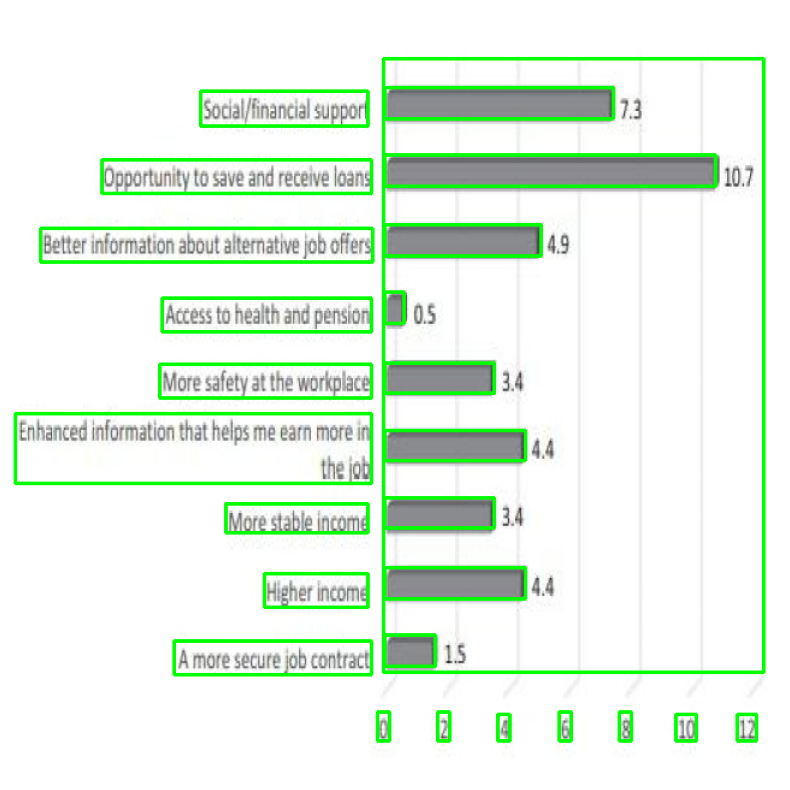

In [117]:
class_names=['plot', 'chart_title', 'axis_title', 'tick_label', 'marker','visual_element']
# plot Bounding Box
img_with_bbox = plot_bbox(matched_image_path[0], objects=object_txt, class_names=class_names)

# show
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()